# House 4 — SNN Energy Forecasting

Clean SNN experiment using the REFIT House 4 data.

**Setup**
- 15-minute resampling
- 24 × 15-minute input window (6 hours)
- Inputs: Aggregate + 9 appliance channels + hour sin/cos + aggregate rate-of-change
- Input features standardized using **training data only**
- Target transformed with **log1p** and standardized using a training-only target scaler
- Predictions converted back to Watts with **expm1** and clipped at zero
- 2-layer LIF SNN with a direct aggregate rate-of-change skip connection
- Temporal readout combining max-membrane pooling and attention-weighted pooling
- Peak-weighted asymmetric MSE with one-step rate-of-change matching loss
- AdamW
- Early stopping with best validation checkpoint
- Peak MAE, peak RMSE, and peak amplitude ratio reported in Watts


In [1]:
# ============================================================
# 1. Imports
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class PeakWeightedLoss(nn.Module):
    def __init__(self, alpha=2.0, beta=0.5, threshold_quantile=0.85):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.threshold_quantile = threshold_quantile
        self.base_mse = nn.MSELoss(reduction="none")

    def forward(self, pred, target, previous_target=None):
        loss_elemental = self.base_mse(pred, target)
        threshold = torch.quantile(target.detach(), self.threshold_quantile)
        under_predict_mask = (target > pred) & (target > threshold)
        weights = torch.where(
            under_predict_mask,
            torch.full_like(target, self.alpha),
            torch.ones_like(target)
        )
        weighted_loss = (loss_elemental * weights).mean()

        if previous_target is not None:
            diff_pred = pred - previous_target
            diff_target = target - previous_target
            deriv_loss = nn.functional.mse_loss(diff_pred, diff_target)
        elif pred.shape[-1] > 1:
            diff_pred = pred[..., 1:] - pred[..., :-1]
            diff_target = target[..., 1:] - target[..., :-1]
            deriv_loss = nn.functional.mse_loss(diff_pred, diff_target)
        else:
            deriv_loss = pred.new_tensor(0.0)

        return weighted_loss + self.beta * deriv_loss


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_PATH = "/home/ahaandesai/Dev/FYP/data/House_4.csv"

WINDOW = 24          # 24 x 15 min = 6 hours
HORIZON = 1          # next 15-minute interval

BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

HIDDEN_1 = 32
HIDDEN_2 = 16
BETA = 0.9

PATIENCE = 7

print("Window:", WINDOW)
print("Horizon:", HORIZON)
print("Learning rate:", LEARNING_RATE)
print("Beta:", BETA)


Window: 24
Horizon: 1
Learning rate: 0.0001
Beta: 0.9


In [3]:
# ============================================================
# 3. Load and preprocess House 4
# ============================================================

df = pd.read_csv(DATA_PATH)

df["Time"] = pd.to_datetime(df["Time"])

df = (
    df
    .sort_values("Time")
    .reset_index(drop=True)
)

power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

# Keep only required columns
df = df[["Time"] + power_cols].copy()

# 15-minute average
df = (
    df
    .set_index("Time")[power_cols]
    .resample("15min")
    .mean()
    .dropna()
    .reset_index()
)

print("15-minute shape:", df.shape)
print("Time range:", df["Time"].min(), "→", df["Time"].max())


15-minute shape: (53375, 11)
Time range: 2013-10-11 10:15:00 → 2015-07-07 09:45:00


In [4]:
# ============================================================
# 4. Create time features, rate-of-change, and target
# ============================================================

hour = df["Time"].dt.hour + df["Time"].dt.minute / 60.0

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Change from the previous 15-minute aggregate.
# shift(1) means this uses only past information.
df["agg_diff"] = df["Aggregate"].diff()

# First row has no previous value.
df["agg_diff"] = df["agg_diff"].fillna(0)

# Future aggregate target.
df["Target"] = df["Aggregate"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)


Final shape: (53374, 15)


count    53374.000000
mean       379.428953
std        321.179805
min          0.000000
50%        320.727188
75%        470.629297
90%        618.071592
95%        801.759808
99%       1630.318950
max       7814.576271
Name: Target, dtype: float64

Percentiles:
P50: 320.73 W
P75: 470.63 W
P90: 618.07 W
P95: 801.76 W
P99: 1630.32 W
Maximum: 7814.58 W


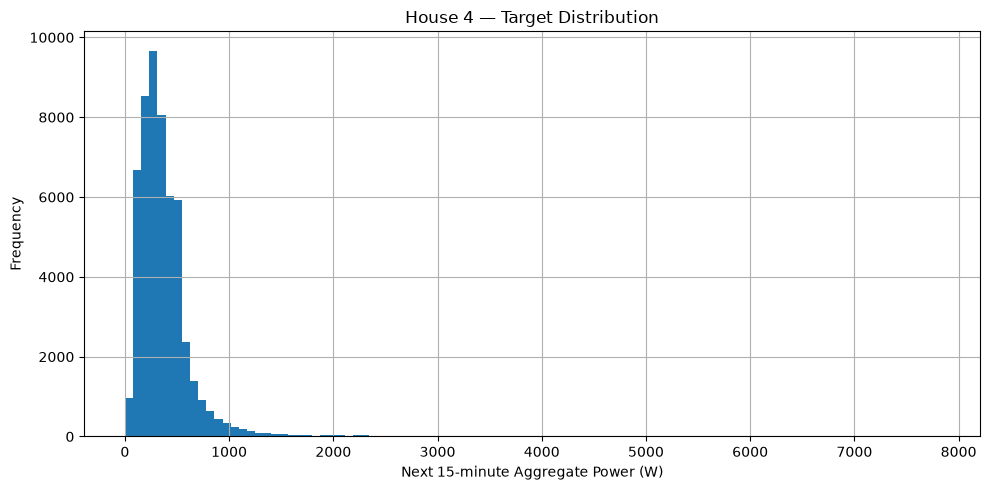

In [5]:
# ============================================================
# 5. Target distribution
# ============================================================

target = df["Target"].values

print(df["Target"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {np.percentile(target, p):.2f} W")

print(f"Maximum: {target.max():.2f} W")

plt.figure(figsize=(10, 5))
plt.hist(target, bins=100)
plt.xlabel("Next 15-minute Aggregate Power (W)")
plt.ylabel("Frequency")
plt.title("House 4 — Target Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# ============================================================
# 6. Chronological train / validation / test split
# ============================================================

n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (37361, 15)
Val:   (8006, 15)
Test:  (8007, 15)


In [11]:
# ============================================================
# 7. Feature scaling
# ============================================================

# Power/appliance input scaler
power_scaler = StandardScaler()

train_power_scaled = power_scaler.fit_transform(
    train_df[power_cols]
)

val_power_scaled = power_scaler.transform(
    val_df[power_cols]
)

test_power_scaled = power_scaler.transform(
    test_df[power_cols]
)


# Aggregate-difference scaler
diff_scaler = StandardScaler()

train_df["agg_diff_scaled"] = diff_scaler.fit_transform(
    train_df[["agg_diff"]]
).ravel()

val_df["agg_diff_scaled"] = diff_scaler.transform(
    val_df[["agg_diff"]]
).ravel()

test_df["agg_diff_scaled"] = diff_scaler.transform(
    test_df[["agg_diff"]]
).ravel()


# Log-transform and standardize the target using training data only.
target_scaler = StandardScaler()
train_target_log = np.log1p(
    np.clip(train_df[["Target"]].values, 0, None)
)
target_scaler.fit(train_target_log)

print("Log target mean:", target_scaler.mean_[0])
print("Log target std: ", target_scaler.scale_[0])


Log target mean: 5.745100749659243
Log target std:  0.6404214192340859


In [12]:
# ============================================================
# 8. Create temporal sequences
# ============================================================

feature_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9",
    "hour_sin",
    "hour_cos",
    "agg_diff_scaled"
]

def create_sequences(power_scaled, df_split, window=24):
    X = []
    y = []
    previous_y = []

    hour_sin = df_split["hour_sin"].values
    hour_cos = df_split["hour_cos"].values
    agg_diff = df_split["agg_diff_scaled"].values
    target_log_scaled = target_scaler.transform(
        np.log1p(np.clip(df_split[["Target"]].values, 0, None))
    ).ravel()

    for i in range(len(power_scaled) - window):
        sequence = np.column_stack([
            power_scaled[i:i + window],
            hour_sin[i:i + window],
            hour_cos[i:i + window],
            agg_diff[i:i + window]
        ])

        previous_target = target_log_scaled[i + window - 1]
        target = target_log_scaled[i + window]

        X.append(sequence)
        previous_y.append(previous_target)
        y.append(target)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        np.asarray(previous_y, dtype=np.float32).reshape(-1, 1)
    )


X_train, y_train, previous_y_train = create_sequences(
    train_power_scaled, train_df, WINDOW
)

X_val, y_val, previous_y_val = create_sequences(
    val_power_scaled, val_df, WINDOW
)

X_test, y_test, previous_y_test = create_sequences(
    test_power_scaled, test_df, WINDOW
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)


X_train: (37337, 24, 13)
y_train: (37337, 1)
X_val:   (7982, 24, 13)
y_val:   (7982, 1)
X_test:  (7983, 24, 13)
y_test:  (7983, 1)


In [17]:
# ============================================================
# 9. DataLoaders
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train),
        torch.tensor(previous_y_train)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val),
        torch.tensor(previous_y_val)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test),
        torch.tensor(previous_y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 292
Validation batches: 63
Test batches: 63


In [18]:
# ============================================================
# 10. SNN — skip connection and temporal pooled readout
# ============================================================

class SNNForecaster(nn.Module):

    def __init__(
        self,
        input_size=13,
        hidden1=32,
        hidden2=16,
        beta=0.9,
        pool_mix=0.5
    ):
        super().__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden1
        )

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(
            hidden1,
            hidden2
        )

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        # The final input feature is the standardized aggregate rate-of-change.
        self.skip = nn.Linear(1, hidden2)
        self.attention = nn.Linear(hidden2, 1)
        self.output = nn.Linear(hidden2, 1)
        self.pool_mix = pool_mix

    def forward(self, x):

        # x = [batch, time, features]
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        readout_states = []

        for t in range(x.size(1)):

            cur1 = self.fc1(
                x[:, t, :]
            )

            spk1, mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.fc2(
                spk1
            )

            _, mem2 = self.lif2(
                cur2,
                mem2
            )

            # Bypass temporal LIF decay for sharp aggregate changes.
            rate_of_change = x[:, t, -1:].unsqueeze(-1)
            skip_state = self.skip(rate_of_change.squeeze(-1))
            readout_states.append(mem2 + skip_state)

        states = torch.stack(readout_states, dim=1)
        max_state = states.max(dim=1).values
        attention_scores = self.attention(states).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        attention_state = torch.sum(
            states * attention_weights.unsqueeze(-1),
            dim=1
        )

        pooled_state = (
            self.pool_mix * max_state
            + (1.0 - self.pool_mix) * attention_state
        )
        return self.output(pooled_state)


model = SNNForecaster(
    input_size=X_train.shape[-1],
    hidden1=HIDDEN_1,
    hidden2=HIDDEN_2,
    beta=BETA
).to(DEVICE)

print(model)

print(
    "\nTrainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


SNNForecaster(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (lif2): Leaky()
  (skip): Linear(in_features=1, out_features=16, bias=True)
  (attention): Linear(in_features=16, out_features=1, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Trainable parameters: 1042


In [19]:
# ============================================================
# 11. Train with early stopping
# ============================================================

criterion = PeakWeightedLoss(
    alpha=2.0,
    beta=0.5,
    threshold_quantile=0.85
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()
    train_total = 0.0

    for xb, yb, previous_yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        previous_yb = previous_yb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb, previous_yb)
        loss.backward()
        optimizer.step()

        train_total += loss.item()

    train_loss = train_total / len(train_loader)
    train_losses.append(train_loss)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()
    val_total = 0.0

    with torch.no_grad():
        for xb, yb, previous_yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            previous_yb = previous_yb.to(DEVICE)

            pred = model(xb)
            loss = criterion(pred, yb, previous_yb)
            val_total += loss.item()

    val_loss = val_total / len(val_loader)
    val_losses.append(val_loss)

    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch+1}"
        )
        break


# Restore best validation checkpoint
model.load_state_dict(best_state)

print(
    f"\nBest epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)


Epoch 01/50 | Train 1.734953 | Val 1.431223
Epoch 02/50 | Train 1.617585 | Val 1.360516
Epoch 03/50 | Train 1.576170 | Val 1.329801
Epoch 04/50 | Train 1.551598 | Val 1.306884
Epoch 05/50 | Train 1.534047 | Val 1.294408
Epoch 06/50 | Train 1.519311 | Val 1.284660
Epoch 07/50 | Train 1.510232 | Val 1.264821
Epoch 08/50 | Train 1.500995 | Val 1.252323
Epoch 09/50 | Train 1.494296 | Val 1.242635
Epoch 10/50 | Train 1.486988 | Val 1.234855
Epoch 11/50 | Train 1.479467 | Val 1.233772
Epoch 12/50 | Train 1.472606 | Val 1.222083
Epoch 13/50 | Train 1.468157 | Val 1.224940
Epoch 14/50 | Train 1.465045 | Val 1.219567
Epoch 15/50 | Train 1.461088 | Val 1.210669
Epoch 16/50 | Train 1.457936 | Val 1.206588
Epoch 17/50 | Train 1.454609 | Val 1.202614
Epoch 18/50 | Train 1.450351 | Val 1.205119
Epoch 19/50 | Train 1.447424 | Val 1.192836
Epoch 20/50 | Train 1.445592 | Val 1.196468
Epoch 21/50 | Train 1.442824 | Val 1.194727
Epoch 22/50 | Train 1.442260 | Val 1.191893
Epoch 23/50 | Train 1.438183 | V

In [20]:
# ============================================================
# 13. Test predictions
# ============================================================

model.eval()

pred_scaled = []
actual_scaled = []

with torch.no_grad():
    for xb, yb, _ in test_loader:
        pred = model(
            xb.to(DEVICE)
        )

        pred_scaled.append(
            pred.cpu().numpy()
        )

        actual_scaled.append(
            yb.numpy()
        )

pred_scaled = np.concatenate(
    pred_scaled
).reshape(-1, 1)

actual_scaled = np.concatenate(
    actual_scaled
).reshape(-1, 1)


def inverse_target_transform(values_scaled):
    values_log = target_scaler.inverse_transform(
        np.asarray(values_scaled).reshape(-1, 1)
    )
    return np.maximum(
        np.expm1(values_log),
        0.0
    ).ravel()


pred_watts = inverse_target_transform(pred_scaled)
actual_watts = inverse_target_transform(actual_scaled)

print("Predictions:", pred_watts.shape)


Predictions: (7983,)


In [22]:
# ============================================================
# 13. Test predictions
# ============================================================

model.eval()

pred_scaled = []
actual_scaled = []

with torch.no_grad():
    for xb, yb, previous_yb in test_loader:
        pred = model(
            xb.to(DEVICE)
        )

        pred_scaled.append(
            pred.cpu().numpy()
        )

        actual_scaled.append(
            yb.numpy()
        )

pred_scaled = np.concatenate(
    pred_scaled
).reshape(-1, 1)

actual_scaled = np.concatenate(
    actual_scaled
).reshape(-1, 1)


def inverse_target_transform(values_scaled):
    values_log = target_scaler.inverse_transform(
        np.asarray(values_scaled).reshape(-1, 1)
    )
    return np.maximum(
        np.expm1(values_log),
        0.0
    ).ravel()


pred_watts = inverse_target_transform(pred_scaled)
actual_watts = inverse_target_transform(actual_scaled)

print("Predictions:", pred_watts.shape)


Predictions: (7983,)


In [23]:
# ============================================================
# 14. Evaluation
# ============================================================

def evaluate_power(actual, pred, name, peak_quantile=0.90):

    actual = np.asarray(actual).ravel()
    pred = np.asarray(pred).ravel()

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    r2 = r2_score(
        actual,
        pred
    )

    peak_threshold = np.quantile(
        actual,
        peak_quantile
    )
    peak_mask = actual >= peak_threshold

    peak_mae = mean_absolute_error(
        actual[peak_mask],
        pred[peak_mask]
    )

    peak_rmse = np.sqrt(
        mean_squared_error(
            actual[peak_mask],
            pred[peak_mask]
        )
    )

    actual_max = actual.max()
    pred_max = pred.max()
    peak_ratio = pred_max / actual_max if actual_max > 0 else np.nan

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"MAE                  : {mae:.2f} W")
    print(f"RMSE                 : {rmse:.2f} W")
    print(f"R²                   : {r2:.4f}")
    print(f"Peak threshold (P{peak_quantile:.0%}) : {peak_threshold:.2f} W")
    print(f"Peak MAE             : {peak_mae:.2f} W")
    print(f"Peak RMSE            : {peak_rmse:.2f} W")
    print(f"Actual max           : {actual_max:.2f} W")
    print(f"Pred max             : {pred_max:.2f} W")
    print(f"Peak amplitude ratio : {peak_ratio:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Peak_MAE": peak_mae,
        "Peak_RMSE": peak_rmse,
        "Actual_Max": actual_max,
        "Pred_Max": pred_max,
        "Peak_Ratio": peak_ratio
    }


result = evaluate_power(
    actual_watts,
    pred_watts,
    "SNN — House 4"
)



SNN — House 4
MAE                  : 149.92 W
RMSE                 : 265.45 W
R²                   : 0.0502
Peak threshold (P90%) : 571.53 W
Peak MAE             : 527.97 W
Peak RMSE            : 740.41 W
Actual max           : 4569.04 W
Pred max             : 665.41 W
Peak amplitude ratio : 0.1456


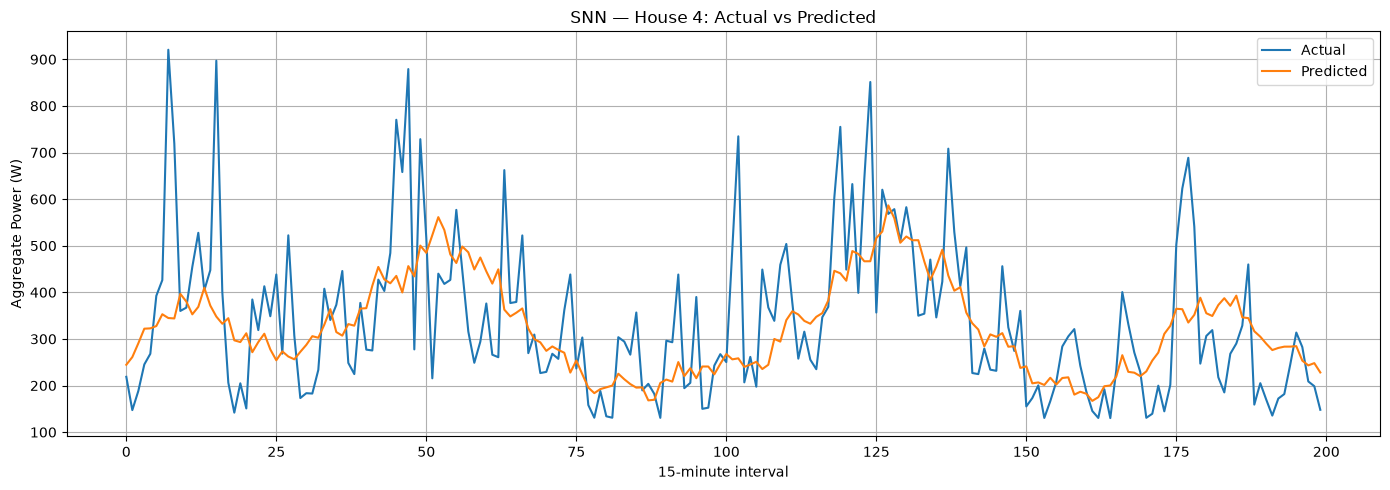

In [24]:
# ============================================================
# 15. Actual vs predicted — first 200 test intervals
# ============================================================

points = min(
    200,
    len(actual_watts)
)

plt.figure(figsize=(14, 5))

plt.plot(
    actual_watts[:points],
    label="Actual"
)

plt.plot(
    pred_watts[:points],
    label="Predicted"
)

plt.xlabel("15-minute interval")
plt.ylabel("Aggregate Power (W)")
plt.title("SNN — House 4: Actual vs Predicted")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
# ============================================================
# 16. Peak diagnostic
# ============================================================

p90 = np.percentile(
    actual_watts,
    90
)

peak_mask = actual_watts >= p90

print("P90 threshold:", f"{p90:.2f} W")
print(
    "Actual mean at P90+:",
    f"{actual_watts[peak_mask].mean():.2f} W"
)
print(
    "Predicted mean at P90+:",
    f"{pred_watts[peak_mask].mean():.2f} W"
)

print(
    "Actual maximum:",
    f"{actual_watts.max():.2f} W"
)

print(
    "Predicted maximum:",
    f"{pred_watts.max():.2f} W"
)


P90 threshold: 571.53 W
Actual mean at P90+: 905.03 W
Predicted mean at P90+: 377.05 W
Actual maximum: 4569.04 W
Predicted maximum: 665.41 W


## Next experiment

Do **not** change the architecture immediately if this run is poor.

Use this run to determine:

- If peaks are still badly underestimated → try a peak-aware loss.
- If validation loss starts rising → early stopping should already select the best epoch.
- If the model follows the signal but lacks long-term context → test `WINDOW = 48` and `WINDOW = 96`.
- If this works substantially better on House 4 → keep House 4 and continue SNN-specific experiments.

The important thing is that all predictions are converted back to **Watts** before evaluation.
